# Lab: การตรวจจับวัตถุบนวิดีโอด้วย Ultralytics YOLOE-26 (Open-Vocabulary Object Detection & Segmentation)

ยินดีต้อนรับสู่ Lab การใช้งาน **YOLOE-26** ซึ่งเป็นโมเดล Open-Vocabulary (ตรวจจับและแบ่งส่วนวัตถุตามคำสั่งของนักพัฒนาได้แบบไม่ต้องเทรนโมเดลใหม่) ล่าสุดจากค่าย **Ultralytics** 

โมเดล YOLOE-26 ได้รับการออกแบบให้ทำงานในลักษณะ NMS-free (ถอดกระบวนการกรองกล่องทับซ้อนที่ซับซ้อนออกเพื่อเพิ่มประสิทธิภาพการคำนวณ) และประมวลผลคำสั่งได้อย่างรวดเร็ว

### สิ่งที่คุณจะได้เรียนรู้ใน Lab นี้:
1. การติดตั้งไลบรารี Ultralytics รุ่นล่าสุดที่รองรับคลาส `YOLOE`
2. การโหลดน้ำหนักโมเดลสำเร็จรูป `yoloe-26s-seg.pt` (หรือรุ่นอื่นที่ต้องการ)
3. การป้อนคำค้นหา (Text Prompts) ด้วย `set_classes` เพื่อกำหนดวัตถุที่ต้องการจับภาพแบบไดนามิก
4. การดึงเฟรมจากวิดีโอ (Video Frame Capture) มาทำนายทีละเฟรมด้วย OpenCV และบันทึกผลลัพธ์เป็นวิดีโอตรวจจับใหม่

## 1. ติดตั้งไลบรารีที่จำเป็น (Installation)

In [ ]:
# อัปเดต ultralytics และติดตั้งโมดูลสำคัญ
!pip install -U ultralytics onnxruntime opencv-python numpy matplotlib

## 2. นำเข้าไลบรารีและตรวจสอบคลาส YOLOE

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request
from ultralytics import YOLOE

print("นำเข้าโมดูลและคลาส YOLOE สำเร็จ!")

นำเข้าโมดูลและคลาส YOLOE สำเร็จ!


## 3. ดาวน์โหลดโมเดล YOLOE-26 และตัวอย่างวิดีโอ

เราจะดาวน์โหลดโมเดล YOLOE-26 ขนาด Small สำหรับทำ Segmentation (`yoloe-26s-seg.pt`) และดาวน์โหลดตัวอย่างวิดีโอ

In [3]:
model_name = "yoloe-26s-seg.pt"

# 1. โหลดโมเดล YOLOE (หากยังไม่มีในเครื่อง ตัวโปรแกรมจะดาวน์โหลดอัตโนมัติ)
print("กำลังโหลดโมเดล YOLOE...")
model = YOLOE(model_name)
print("โหลดโมเดล YOLOE สำเร็จ!")

# 2. ดาวน์โหลดวิดีโอตัวอย่าง
video_url = "https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/person-bicycle-car-detection.mp4"
video_path = "sample_video.mp4"
if not os.path.exists(video_path):
    print("กำลังดาวน์โหลดวิดีโอตัวอย่าง...")
    urllib.request.urlretrieve(video_url, video_path)
    print("ดาวน์โหลดวิดีโอสำเร็จ!")
else:
    print("วิดีโอตัวอย่างพร้อมใช้งานอยู่แล้ว")

กำลังโหลดโมเดล YOLOE...
โหลดโมเดล YOLOE สำเร็จ!
กำลังดาวน์โหลดวิดีโอตัวอย่าง...
ดาวน์โหลดวิดีโอสำเร็จ!


## 4. กำหนดคลาสที่จะค้นหาด้วยข้อความ (Text Prompting)

จุดเด่นของ YOLOE คือเราสามารถระบุข้อความอะไรก็ได้ที่โมเดลเคยเรียนรู้จากชุดข้อมูลขนาดใหญ่เพื่อนำมาค้นหาวัตถุในทันทีโดยไม่ต้องเทรนเพิ่ม

In [5]:
# กำหนดคลาสวัตถุที่ต้องการจับภาพเป็นข้อความภาษาอังกฤษ
prompts = ["person", "bicycle", "car", "backpack"]

# ทำการตั้งค่าคลาสให้กับโมเดล
model.set_classes(prompts)
print(f"ตั้งค่าคลาสตรวจจับเรียบร้อย: {prompts}")

ตั้งค่าคลาสตรวจจับเรียบร้อย: ['person', 'bicycle', 'car', 'backpack']


## 5. ทดสอบตรวจจับบนภาพเฟรมแรกจากวิดีโอ

ดึงภาพเฟรมแรกจากวิดีโอมาทดสอบการทำงานของโมเดล ยืนยันการตรวจจับก่อนประมวลผลทั้งวิดีโอ


0: 384x640 (no detections), 51.4ms
Speed: 4.3ms preprocess, 51.4ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


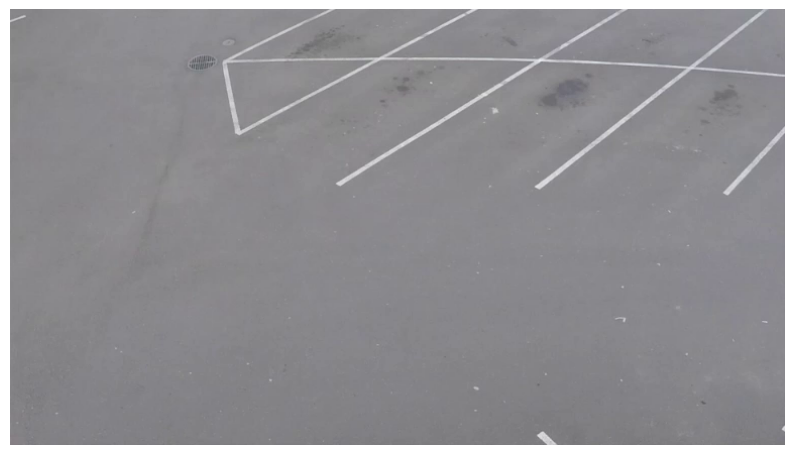

In [6]:
# อ่านวิดีโอเพื่อดึงเฟรมแรก
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    # ทำนายผลลัพธ์บนเฟรมภาพนิ่ง
    results = model.predict(frame, conf=0.25)
    
    # วาดรูปผลลัพธ์ที่ได้จากการทำนาย (Bounding Box และ Mask/Segment)
    annotated_frame = results[0].plot()
    
    # แปลงสีภาพจาก BGR เป็น RGB สำหรับ Matplotlib
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    
    # แสดงผล
    plt.figure(figsize=(10, 6))
    plt.imshow(annotated_frame_rgb)
    plt.axis('off')
    plt.show()
else:
    print("ไม่สามารถดึงเฟรมภาพมาทดสอบได้")

## 6. การตรวจจับและจับภาพบนวิดีโอแบบเฟรมต่อเฟรม (Video Frame Loop)

เราจะเปิดวิดีโอแล้วเขียนโปรแกรมจับเฟรมภาพ (Frame Capture) ทีละเฟรมผ่านคำสั่งของ OpenCV จากนั้นส่งเข้าโมเดล YOLOE เพื่อค้นหาวัตถุตามคลาสที่ตั้งค่าไว้ และรวมผลลัพธ์เข้าด้วยกันเป็นวิดีโอตรวจจับวัตถุสมบูรณ์แบบ

In [9]:
# 1. เปิดวิดีโอต้นฉบับ
cap = cv2.VideoCapture(video_path)

# 2. ดึงข้อมูลคุณสมบัติของวิดีโอ
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"คุณสมบัติวิดีโอ: ขนาด {width}x{height}, FPS: {fps:.2f}, เฟรมทั้งหมด: {total_frames}")

# 3. ตั้งค่า VideoWriter สำหรับบันทึกไฟล์วิดีโอผลลัพธ์
output_video_path = "yoloe_detected_video.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # ใช้ MP4 Codec ในการบันทึก
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

frame_count = 0
print("กำลังประมวลผลวิดีโอด้วย YOLOE-26...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    # ส่งเฟรมไปตรวจจับตามความมั่นใจ (Confidence) ขั้นต่ำ 0.25
    results = model.predict(frame, conf=0.25, verbose=False)
    
    # ดึงเฟรมที่มีการวาดกรอบและการแบ่งส่วนพิกเซล (Segmentation Mask) เรียบร้อยแล้ว
    annotated_frame = results[0].plot()
    
    # เขียนเฟรมผลลัพธ์ลงในไฟล์วิดีโอใหม่
    out.write(annotated_frame)
    
    frame_count += 1
    if frame_count % 50 == 0:
        print(f"ประมวลผลไปแล้ว: {frame_count}/{total_frames} เฟรม ({frame_count/total_frames*100:.1f}%)")

# ปล่อยและคืนทรัพยากรตัวประมวลผลวิดีโอ
cap.release()
out.release()
print(f"\nประมวลผลและบันทึกเสร็จสมบูรณ์! ไฟล์บันทึกไว้ที่: {output_video_path}")

คุณสมบัติวิดีโอ: ขนาด 768x432, FPS: 12.00, เฟรมทั้งหมด: 647
กำลังประมวลผลวิดีโอด้วย YOLOE-26...
ประมวลผลไปแล้ว: 50/647 เฟรม (7.7%)
ประมวลผลไปแล้ว: 100/647 เฟรม (15.5%)
ประมวลผลไปแล้ว: 150/647 เฟรม (23.2%)
ประมวลผลไปแล้ว: 200/647 เฟรม (30.9%)
ประมวลผลไปแล้ว: 250/647 เฟรม (38.6%)
ประมวลผลไปแล้ว: 300/647 เฟรม (46.4%)
ประมวลผลไปแล้ว: 350/647 เฟรม (54.1%)
ประมวลผลไปแล้ว: 400/647 เฟรม (61.8%)
ประมวลผลไปแล้ว: 450/647 เฟรม (69.6%)
ประมวลผลไปแล้ว: 500/647 เฟรม (77.3%)
ประมวลผลไปแล้ว: 550/647 เฟรม (85.0%)
ประมวลผลไปแล้ว: 600/647 เฟรม (92.7%)

ประมวลผลและบันทึกเสร็จสมบูรณ์! ไฟล์บันทึกไว้ที่: yoloe_detected_video.mp4


## 7. วิธีลัดในการทำนายและบันทึกผลวิดีโอแบบบรรทัดเดียว (Bonus)

นอกจากการวนลูปจับภาพทีละเฟรมด้วยตัวเองแล้ว Ultralytics ยังจัดฟังก์ชันลัดที่คุณสามารถสั่งตรวจจับทั้งวิดีโอและเซฟให้อัตโนมัติในบรรทัดเดียวได้

In [ ]:
# ส่งวิดีโอทั้งไฟล์ประมวลผลและเซฟโดยตรง (ตัวโปรแกรมจะสร้างไฟล์ในโฟลเดอร์ runs/segment/predict/)
model.predict(source=video_path, save=True, conf=0.25)